In [1]:
import requests

import pandas as pd
import geopandas as geopd
import numpy as np

from shapely import Point

import matplotlib.pyplot as plt

from tqdm import tqdm

plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

In [2]:
pd.options.display.max_columns = 30
pd.options.display.min_rows = 20
pd.options.display.max_rows = 30

In [3]:
def dict_list_to_df(values):
    """ Used for parsing the request
    """
    df = pd.DataFrame(columns=list(values[0].keys()))
    for item in values:
        new = pd.DataFrame([item])
        df = pd.concat([df, new], ignore_index=True)
    return df

In [6]:
flags = [1, 2 , 3, 4, 101]

In [7]:
flag = flags[2]

url = f'https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.0/odata/Lippu({flag})/Virtaama?'

In [10]:
response = requests.get(url)

In [4]:
meta_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_meta_attributes.csv'
meta = pd.read_csv(meta_path)
original_gauge_ids = list(meta['gauge_id'])
# splitting virtual gauges into original gauges
gauge_ids = []
for gauge_id in original_gauge_ids:
    splits = gauge_id.split('-')
    for split in splits:
        gauge_ids.append(split)
        

## Flags

In [37]:

flows = None
for place_id in tqdm(gauge_ids):
    flow_url = f"https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Virtaama?$filter=Paikka/Paikka_Id%20eq%20{place_id}"
    error_count = 0
    # The flow values are gathered to a temporary dataframe, that contains data of one location.
    place_flow = pd.DataFrame()
    while True:
        flow_batch = pd.DataFrame()
        try:
            response = requests.get(flow_url)
        except error as e:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with request:{e}")
            break

            
        if response.status_code == 200:
            content = response.json()
            keys = content.keys()
        else:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with status code {response.status_code}")
            break
            
        
        values = content['value']

        for i, value in enumerate(values):
            flow_batch.at[i, 'datetime'] = value['Aika'] # Aika == time
            if value['Lippu_id'] is None:
                flow_batch.at[i, str(place_id)] = np.nan
            else:
                flow_batch.at[i, str(place_id)] = int(value['Lippu_id']) # Lippu == flag

        place_flow = pd.concat([place_flow, flow_batch], ignore_index=True)
        
        # is there still content left?
        if 'odata.nextLink' in keys:
            flow_url = content['odata.nextLink']
        else:
            break
        
    
    place_flow = place_flow.set_index(pd.DatetimeIndex(place_flow['datetime']), drop=True)
    place_flow = place_flow.drop('datetime', axis=1)

    if flows is None:
        flows = place_flow
    else:
        flows = pd.merge(flows, place_flow, on='datetime', how='outer')

dst_file_name = 'all_flags'
# uncomment the format you want. Parquet can handle datetime natively
flows.to_parquet(f"{dst_file_name}.parquet")
#flows_to_csv(f"{dst_file_name}.csv")

100%|█████████████████████████████████████████| 328/328 [40:03<00:00,  7.33s/it]


In [47]:
flags = flows

In [66]:
unique_counts = pd.DataFrame({
    col: flags[col].value_counts()
    for col in flags.columns
})
print(unique_counts.sum(axis=1))


1.0       23606.0
2.0       15160.0
3.0      427821.0
4.0         473.0
101.0       588.0
108.0      5373.0
109.0       165.0
111.0        39.0
115.0      8912.0
116.0        73.0
dtype: float64



- 101: Vesistömallijärjestelmästä
- 108: Hetkellisiä arvoja puuttuu
- 109: Limnipaperista luettu arvo
- 111: Arvioitu
- 115: Havainto kakkoslaitteesta

## Remarks

In [11]:

flows = None
for place_id in tqdm(gauge_ids):
    flow_url = f"https://rajapinnat.ymparisto.fi/api/Hydrologiarajapinta/1.1/odata/Virtaama?$filter=Paikka/Paikka_Id%20eq%20{place_id}"
    error_count = 0
    # The flow values are gathered to a temporary dataframe, that contains data of one location.
    place_flow = pd.DataFrame()
    while True:
        flow_batch = pd.DataFrame()
        try:
            response = requests.get(flow_url)
        except error as e:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with request:{e}")
            break

            
        if response.status_code == 200:
            content = response.json()
            keys = content.keys()
        else:
            with open("error_log.txt", 'a') as error_log:
                error_log.write(f"Place {place_id}, error with status code {response.status_code}")
            break
            
        
        values = content['value']

        for i, value in enumerate(values):
            flow_batch.at[i, 'datetime'] = value['Aika'] # Aika == time
            if value['huomautus'] is None:
                flow_batch.at[i, str(place_id)] = ''
            else:
                flow_batch.at[i, str(place_id)] = value['huomautus'] # Lippu == flag

        place_flow = pd.concat([place_flow, flow_batch], ignore_index=True)
        
        # is there still content left?
        if 'odata.nextLink' in keys:
            flow_url = content['odata.nextLink']
        else:
            break
        
    
    place_flow = place_flow.set_index(pd.DatetimeIndex(place_flow['datetime']), drop=True)
    place_flow = place_flow.drop('datetime', axis=1)

    if flows is None:
        flows = place_flow
    else:
        flows = pd.merge(flows, place_flow, on='datetime', how='outer')

dst_file_name = 'flow_remarks'
# uncomment the format you want. Parquet can handle datetime natively
flows.to_parquet(f"{dst_file_name}.parquet")
#flows_to_csv(f"{dst_file_name}.csv")

100%|████████████████████████████████████████████████████| 328/328 [45:12<00:00,  8.27s/it]


In [17]:
flags = pd.read_parquet('all_flags.parquet')
remarks

,896,905,907,908,923,924,929,930,931,933,935,937,938,939,941,...,3544,3551,3558,3568,3581,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1863-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1863-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
remarks = flows.copy()

In [19]:
unique_counts = pd.DataFrame({
    col: remarks[col].value_counts()
    for col in remarks.columns
})
print(unique_counts.sum(axis=1))


                                                                                                                                                                          5928813.0
2.8. alkanut vedenkorkeuden nousu majavan padon aiheuttamaa.                                                                                                                    1.0
=\r\n=\r\n=\r\n=\r\n=\r\n=\r\n=\r\nLiputettiin, koska ei vastaa käyrää                                                                                                          1.0
Arvo on laskettu purkautumiskäyrän avulla limnipaperista luetulla vedenkorkeuden vrk-keskiarvolla, eikä Hydrossa näkyvällä vedenkorkeuden hetkellisellä 08.00 arvolla.       1095.0
Arvot 31.8.-12.10.2023 korjattu pyynnöstä 16.7.2024/MP                                                                                                                          1.0
Arvot laskettu uudestaan hetkellisistä ja tallennettu manuaalisesti insertillä                      

In [21]:
unique_counts.to_csv('/media/iielse/T9/CAMELS-FI_revision/flags/quality checks/text counts.csv')

In [43]:
time = ("1961-01-01", "2023-12-31")
flows = pd.read_parquet('flow/all_flows.parquet')

# There is a duplicate column, removing it
flags = pd.read_parquet('all_flags.parquet')
flags = flags.drop('2687_y', axis=1)
flags = flags.rename({'2687_x': '2687'}, axis=1)
remarks = pd.read_parquet('flow_remarks.parquet')
remarks =remarks.drop('2687_y', axis=1)
remarks = remarks.rename({'2687_x': '2687'}, axis=1)

In [44]:
flows = flows.loc[time[0]: time[1], flags.columns]
flags = flags.loc[time[0]: time[1]]
remarks = remarks.loc[time[0]: time[1]]

In [45]:
flows.notna()

,896,905,907,908,923,924,929,930,931,933,935,937,938,939,941,...,3544,3551,3558,3568,3581,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1961-01-01,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-02,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-03,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-04,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-05,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-06,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-07,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-08,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1961-01-09,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
flags

,896,905,907,908,923,924,929,930,931,933,935,937,938,939,941,...,3544,3551,3558,3568,3581,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1961-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
remarks

,896,905,907,908,923,924,929,930,931,933,935,937,938,939,941,...,3544,3551,3558,3568,3581,3602,3605,3607,3678,3719,3727,3728,3850,3907,3975
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1961-01-01,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-02,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-03,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-04,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-05,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-06,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-07,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-08,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1961-01-09,None,None,None,None,None,,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


## Filling valid observations with no flags with zero

In [50]:
filled_flags = flags.fillna(0).where(flows.notna())

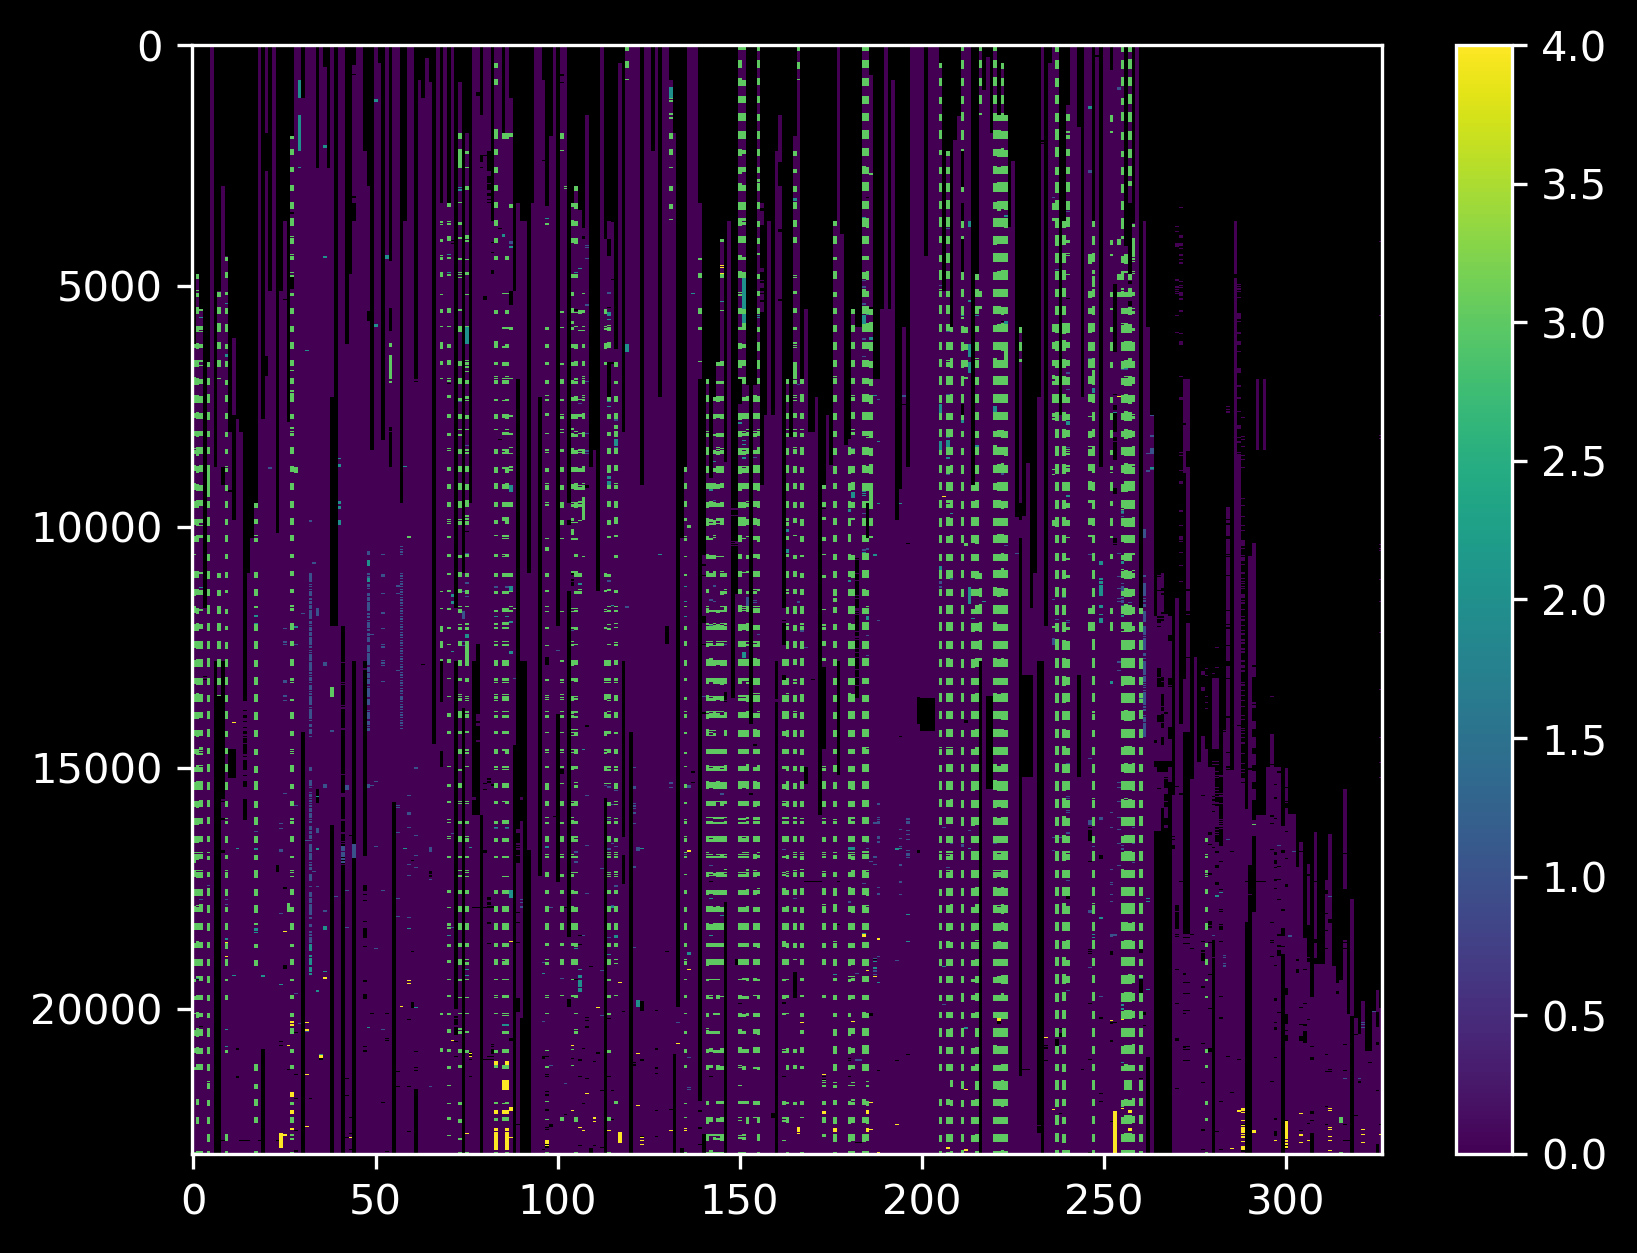

In [53]:
imax = plt.imshow(filled_flags, aspect='auto', vmax=4, interpolation='none')
plt.colorbar()

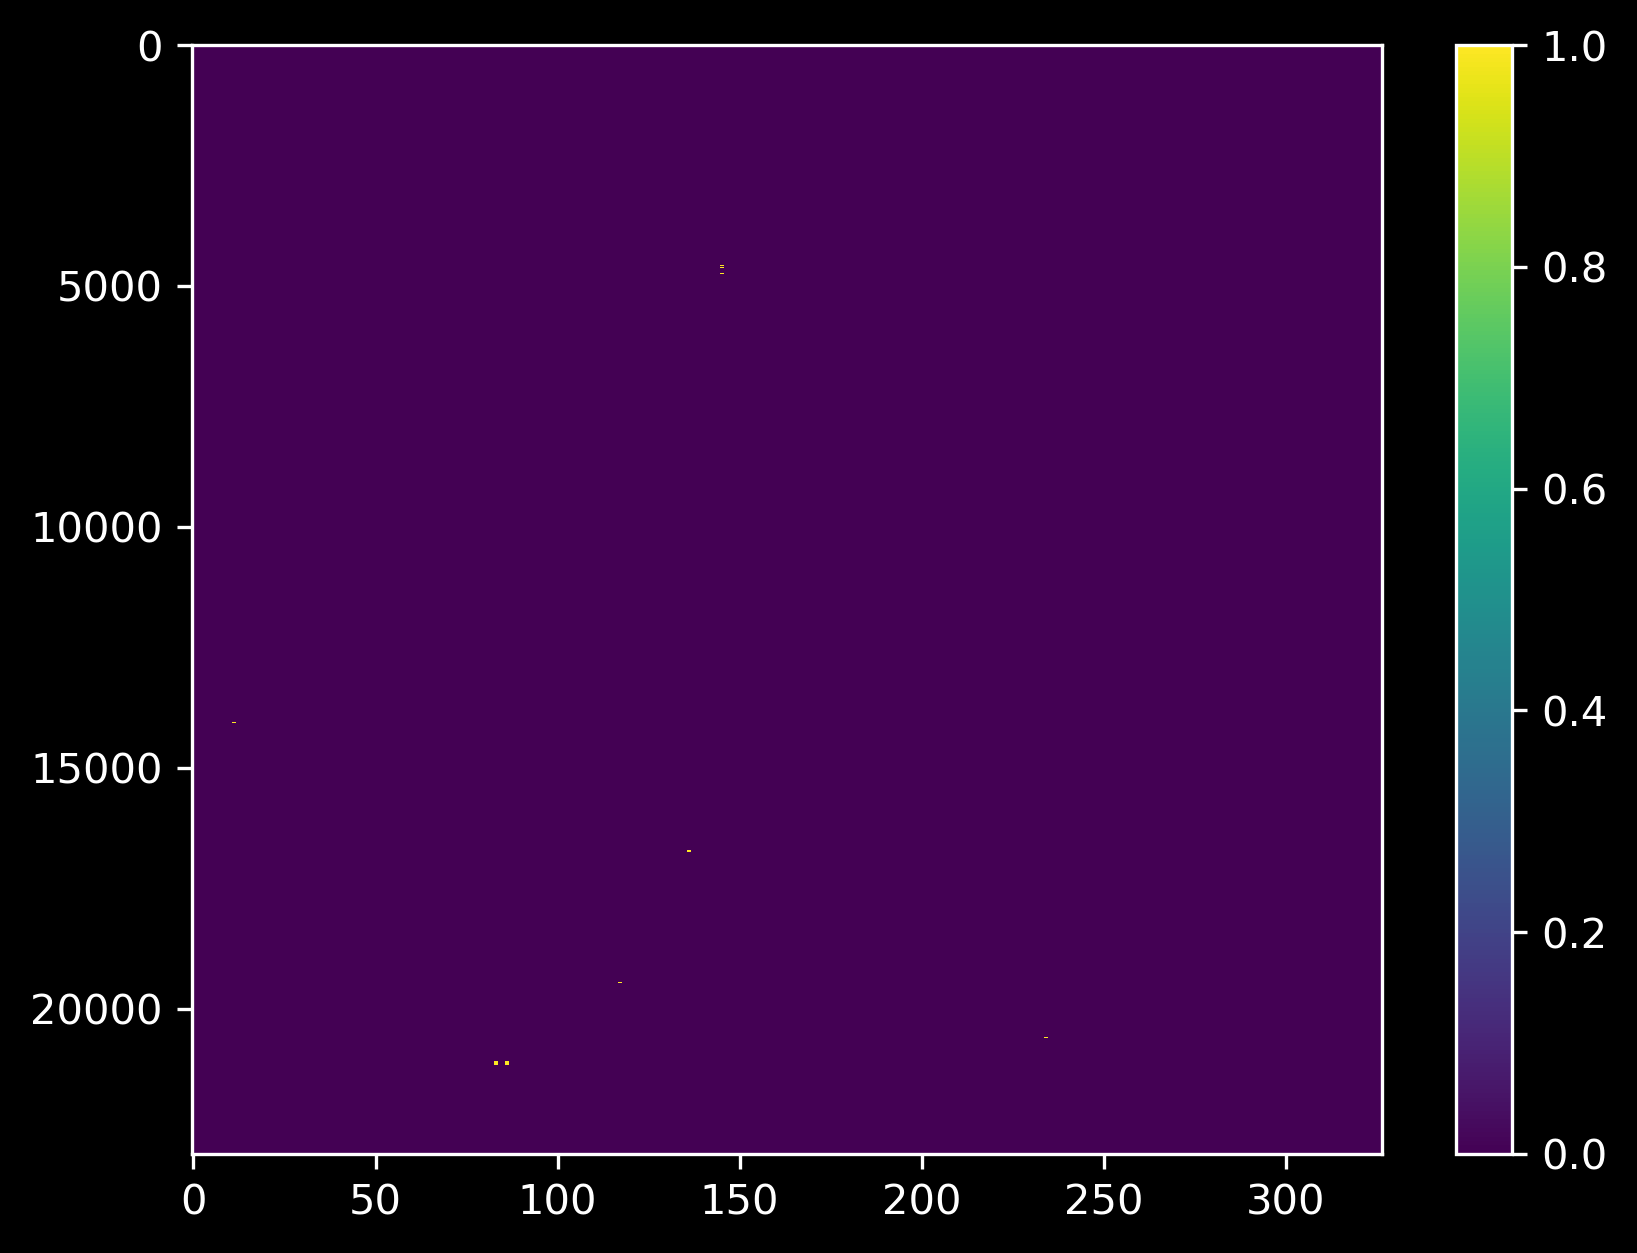

In [153]:
imax = plt.imshow(filled_flags==4, aspect='auto', interpolation='none')
plt.colorbar()

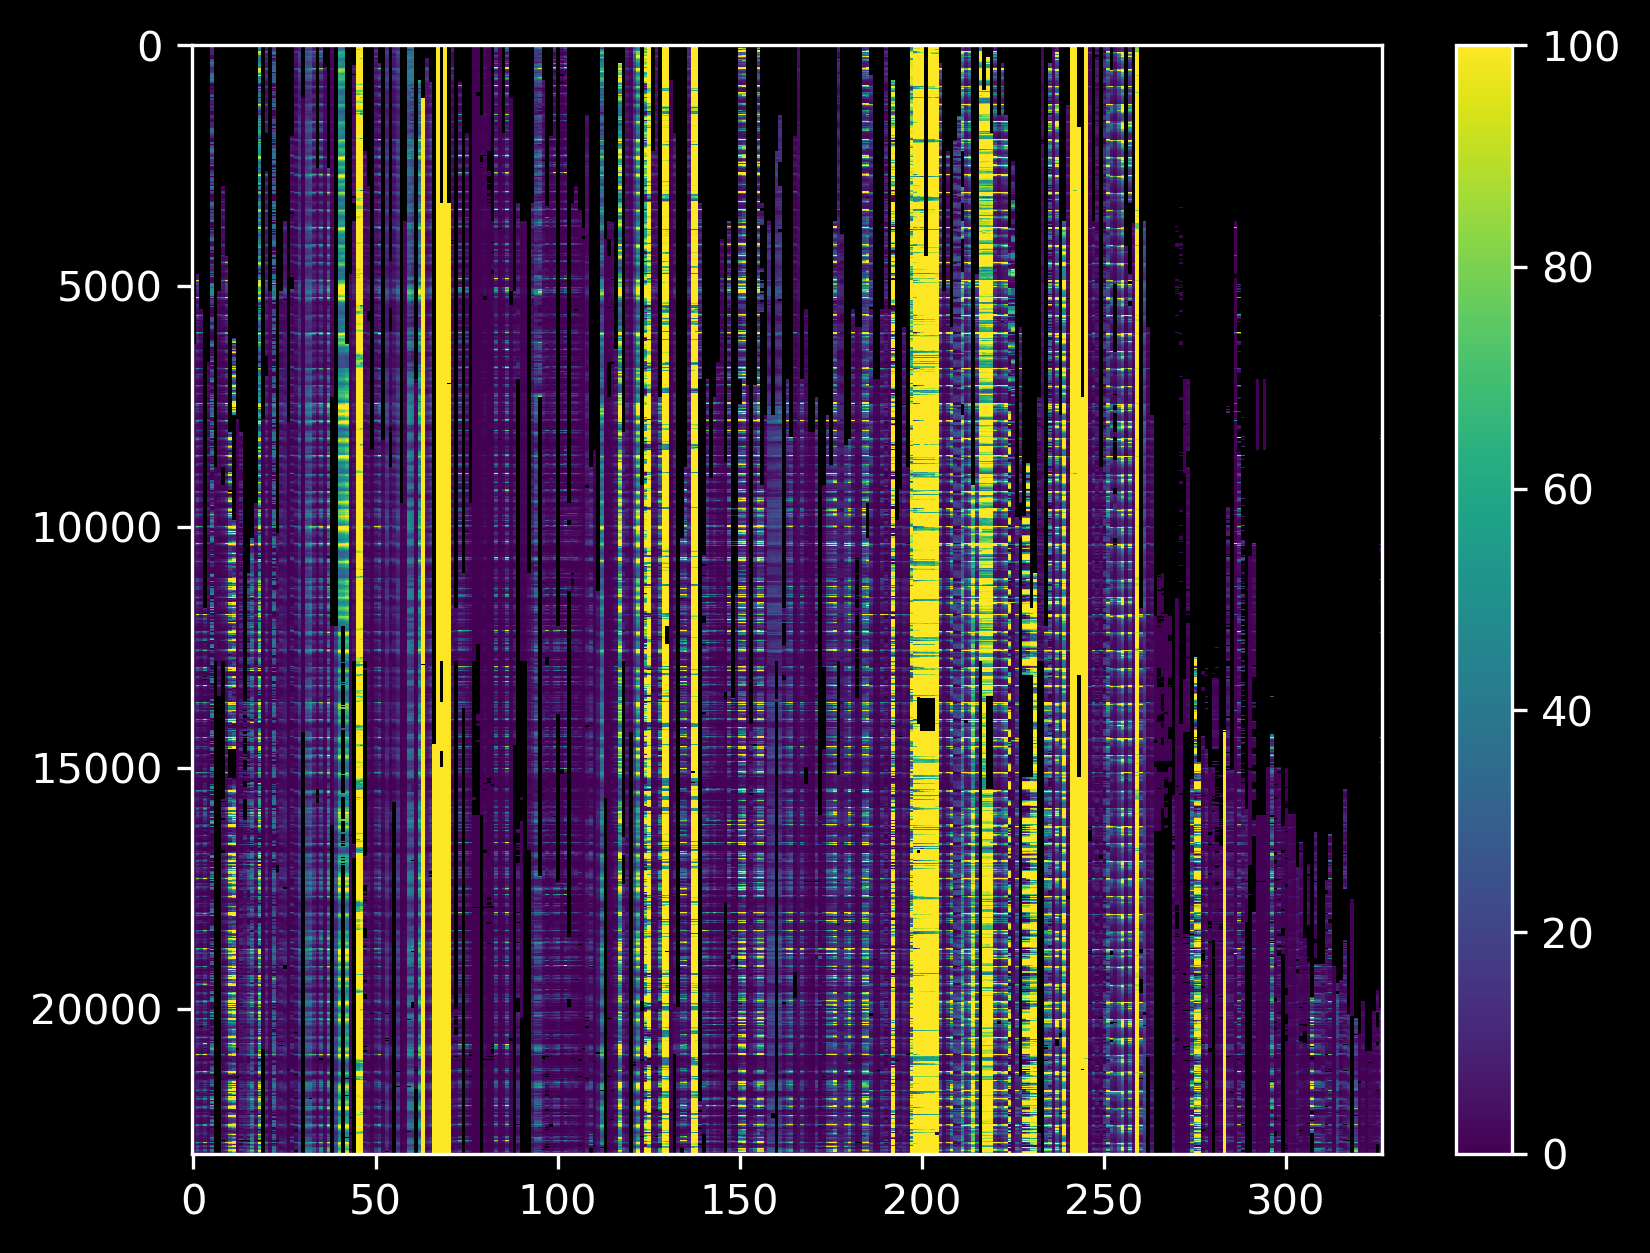

In [58]:
imax = plt.imshow(flows, aspect='auto', vmax=100,  interpolation='none')
plt.colorbar()

In [148]:
filled_flags.iloc[18339].name

Timestamp('2011-03-19 00:00:00')

In [62]:
filled_flags
unique_counts = pd.DataFrame({
    col: filled_flags[col].value_counts()
    for col in filled_flags.columns
})
print(unique_counts.sum(axis=1))


0.0      4669213.0
1.0        23456.0
2.0        13282.0
3.0       393023.0
4.0          342.0
101.0        562.0
108.0       2129.0
109.0        165.0
111.0         39.0
115.0       4209.0
116.0         42.0
dtype: float64


In [63]:
filled_flags.to_csv('/media/iielse/T9/CAMELS-FI_revision/flags/discharge_flags.csv')

## Replacing the Finnish remarks with translations

In [122]:
remark_counts = pd.read_excel('/media/iielse/T9/CAMELS-FI_revision/flags/quality checks/remark counts.ods')

In [123]:
translations = remark_counts.loc[1:129, ['Original', 'Translation']]

In [124]:
translation_dict = dict(zip(translations['Original'], translations['Translation']))

In [125]:
translated = remarks.replace(translation_dict)

In [126]:
trans_success = ((remarks == translated) & (remarks != ''))
true_indices = trans_success.stack()[trans_success.stack()].index.tolist()
true_indices

[(Timestamp('1961-05-17 00:00:00'), '1331'),
 (Timestamp('1966-05-11 00:00:00'), '1213'),
 (Timestamp('1972-05-23 00:00:00'), '1374'),
 (Timestamp('1973-05-20 00:00:00'), '1374'),
 (Timestamp('1980-12-13 00:00:00'), '1414')]

In [96]:
extra_translations = {}
for i, j in true_indices:
    print(i, j)
    origin = translated.at[i, j]
    print(origin)
    extra_translations[origin] =  input()

1961-05-17 00:00:00 1331
Lisättiin lippu maaliskuussa 2017, koska poikkeaa useita kuutioita purkautumiskäyrän arvosta. Syy poikkeamaan ei tiedossa.
Lisättiin lippu maaliskuussa 2017, koska poikkeaa useita kuutioita purkautumiskäyrän arvosta. Syy poikkeamaan ei tiedossa.
Lisättiin lippu maaliskuussa 2017, koska poikkeaa useita kuutioita purkautumiskäyrän arvosta. Syy poikkeamaan ei tiedossa.
Lisättiin lippu maaliskuussa 2017, koska poikkeaa useita kuutioita purkautumsikäyrän antamasta arvosta. Syy ei tiedossa.


 Value does not match the rating curve, deviation is several cubic meters


1966-05-11 00:00:00 1213
Oli 327. Korjattiin vastaamaan käyrää
Oli 327. Korjattiin vastaamaan käyrää
Oli 327. Korjattiin vastaamaan käyrää.


 Corrected to match the rating curve, was 327


1972-05-23 00:00:00 1374
=
=
=
=
=
=
=
Liputettiin, koska ei vastaa käyrää


 Value does not match the rating curve


1973-05-20 00:00:00 1374
Oli 368. Tulkittiin lyöntivirheeksi. Vastaa nyt käyrää (268).
Oli 368. Tulkittiin lyöntivirheeksi. Vastaa nyt käyrää (268).


 Corrected to match the rating curve, was 368 and assumed to be typo


1980-12-13 00:00:00 1414
Joulukuussa 1980 toisen uoman yli johtava silta sortui
Joulukuussa 1980 toisen uoman yli johtava silta sortui
Joulukuussa 1980 toisen uoman yli johtava silta sortui


 The bridge leading over one of the streams collapsed in December 1980


In [127]:
translation_dict.update(extra_translations)

In [128]:
translated = remarks.replace(translation_dict)

In [129]:
trans_success = ((remarks == translated) & (remarks != ''))
true_indices = trans_success.stack()[trans_success.stack()].index.tolist()
true_indices

[]

## Success!

In [130]:
unique_counts = pd.DataFrame({
    col: translated[col].value_counts()
    for col in translated.columns
})
print(unique_counts.sum(axis=1))

                                                                                                                                                                                 5111450.0
Added a flag that had disappeared at some point                                                                                                                                        2.0
Added spillover information received from the power plant                                                                                                                              8.0
Compare to instantenuous values of Siikajoki                                                                                                                                           1.0
Corrected to match the rating curve                                                                                                                                                    6.0
Corrected to match the rating curve, suspected to be caused by er

In [135]:
unique_counts.index

Index(['', 'Added a flag that had disappeared at some point',
       'Added spillover information received from the power plant',
       'Compare to instantenuous values of Siikajoki',
       'Corrected to match the rating curve',
       'Corrected to match the rating curve, suspected to be caused by error in reading the values',
       'Corrected to match the rating curve, was 0.15 and assumed to be typo',
       'Corrected to match the rating curve, was 120',
       'Corrected to match the rating curve, was 121',
       'Corrected to match the rating curve, was 130',
       'Corrected to match the rating curve, was 147, suspected to be caused by error in reading the values',
       'Corrected to match the rating curve, was 15.5',
       'Corrected to match the rating curve, was 16.8. Suspected to be caused by error in reading the values',
       'Corrected to match the rating curve, was 17.9. Suspected to be caused by error in reading the values',
       'Corrected to match the ratin

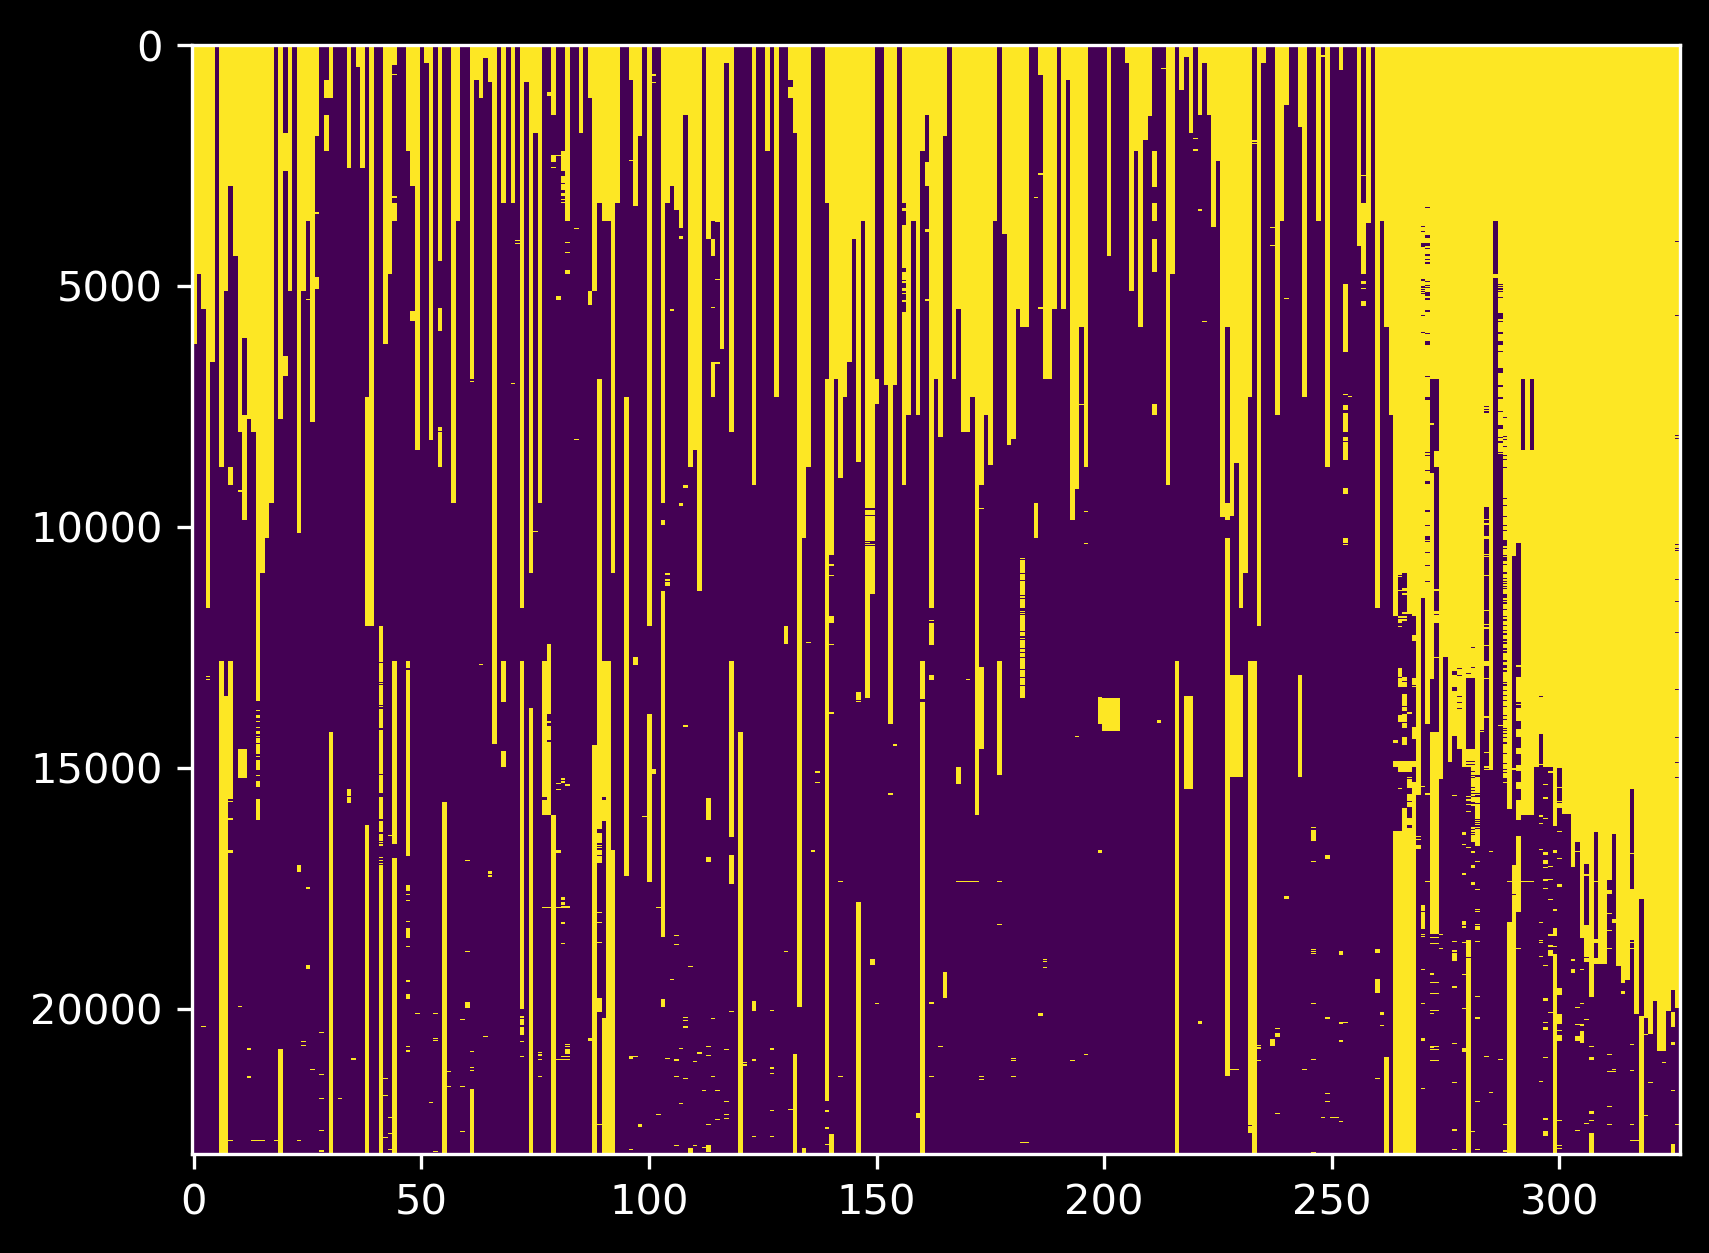

In [132]:
plt.imshow((translated != '') & (translated is not None), aspect='auto',  interpolation='none')

In [133]:
translated.to_csv('/media/iielse/T9/CAMELS-FI_revision/flags/discharge_remarks.csv')